# California Housing Price Prediction Practice

In this exercise, we will use the California Housing dataset from Scikit-learn.  
We will train a baseline model and a Linear Regression model, then evaluate them using MAE, RMSE, and R².

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline

## 1. Load the Dataset

In [140]:
housing=fetch_california_housing()

## 2. Create Features and Target

`X` contains the input features.  
`y` contains the target house price values.

In [141]:
X=pd.DataFrame(
    data=housing.data,
    columns=housing.feature_names
)
y=housing.target

In [142]:
print(X.head(5))
print(y)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
[4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [143]:
print(X.shape)
print(y.shape)

(20640, 8)
(20640,)


## 3. Train-Test Split

We split the dataset into training and testing data.

In [144]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

## 4. Scale the Features

StandardScaler is used to standardize the feature values.

In [145]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 5. Baseline Model: Dummy Regressor

The dummy model predicts the mean value every time.  
This gives us a simple baseline to compare with.

In [146]:
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)

dummy_preds = dummy.predict(X_test)

In [147]:
dummy_mae = mean_absolute_error(y_test, dummy_preds)
dummy_rmse = np.sqrt(mean_squared_error(y_test, dummy_preds))
dummy_r2 = r2_score(y_test, dummy_preds)

print("Dummy Model MAE:", dummy_mae)
print("Dummy Model RMSE:", dummy_rmse)
print("Dummy Model R2:", dummy_r2)

Dummy Model MAE: 0.9060685490007149
Dummy Model RMSE: 1.1448563543099792
Dummy Model R2: -0.00021908714592466794


## 6. Train Linear Regression Model

In [148]:
model = LinearRegression()
model.fit(X_train, y_train)

linear_preds = model.predict(X_test)

## 7. Evaluate Linear Regression Model

In [149]:
linear_mae = mean_absolute_error(y_test, linear_preds)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_preds))
linear_r2 = r2_score(y_test, linear_preds)

print("Linear Regression MAE:", linear_mae)
print("Linear Regression RMSE:", linear_rmse)
print("Linear Regression R2:", linear_r2)

Linear Regression MAE: 0.5332001304956564
Linear Regression RMSE: 0.7455813830127763
Linear Regression R2: 0.575787706032451


## Key Observations

- The Dummy Regressor is only a baseline model because it predicts the average house value for every record.
- Linear Regression performs better than the Dummy Regressor because it learns relationships between features and the target.
- MAE shows the average prediction error in house value units.
- RMSE gives more penalty to larger errors, so it is useful for checking big mistakes.
- R² shows how much variation in house prices is explained by the model.

## 8. Create an Evaluation Function

This function calculates and prints MAE, RMSE, and R² for any regression model.

In [150]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2:", r2)


In [151]:
evaluate_model(model, X_test, y_test)

MAE: 0.5332001304956564
RMSE: 0.7455813830127763
R2: 0.575787706032451


## 9. Actual vs Predicted Plot

This scatter plot compares actual house prices with predicted house prices.  
The red dashed line represents perfect prediction.

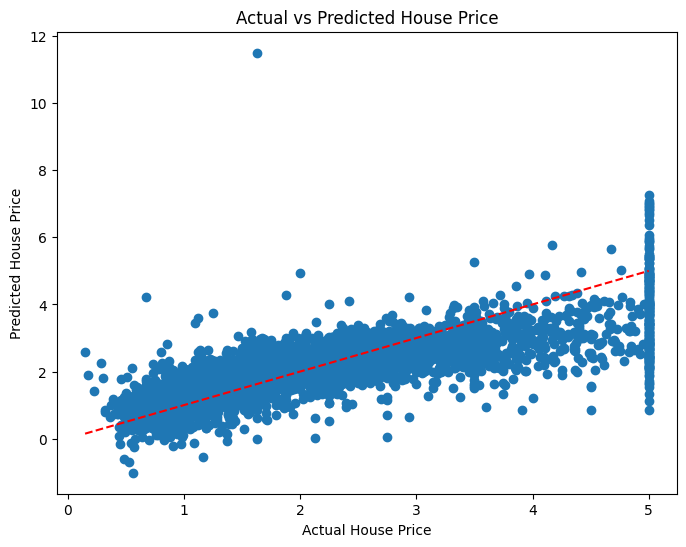

In [152]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, linear_preds)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Price")

plt.show()

## Key Observations

- The model captures the overall increasing trend between actual and predicted house prices.
- Lower-priced houses tend to be slightly overestimated, while higher-priced houses are generally underestimated.
- Predictions are concentrated around the middle range, indicating that the model struggles to accurately predict extreme house prices.

## 10. Residual Plot

Residuals are the differences between actual and predicted values.  
A residual close to 0 means the prediction is close to actual. Positive residual = underprediction. Negative residual = overprediction.

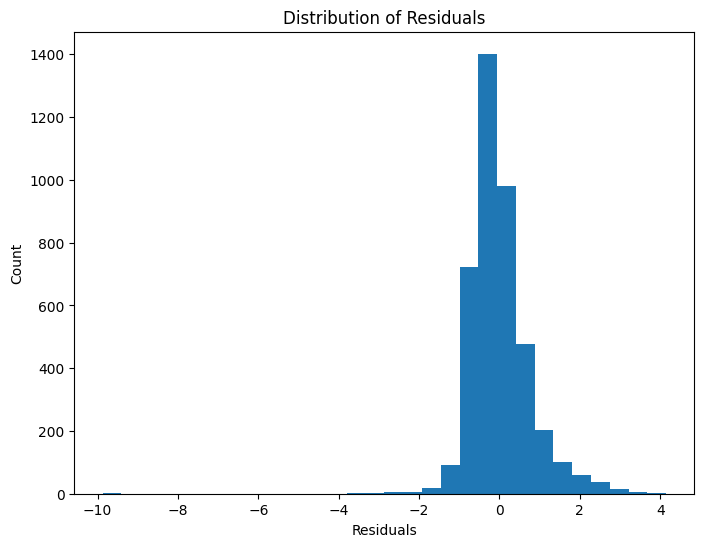

In [153]:
residuals = y_test - linear_preds

plt.figure(figsize=(8, 6))

plt.hist(residuals, bins=30)

plt.xlabel("Residuals")
plt.ylabel("Count")
plt.title("Distribution of Residuals")

plt.show()

## Key Observations

- Most residuals are centered near 0 with a slight leftward shift, indicating the model tends to slightly overpredict house prices on average.
- The prediction errors are concentrated near zero, suggesting that many predictions are reasonably close to the actual values.
- A long tail to the left indicates the model significantly overpredicts a few houses — these are the outliers visible in the scatter plot

## Final Conclusion

The Linear Regression model performs better than the baseline Dummy Regressor.  
However, the scatter plot and residual distribution show that the model is not perfect.  
This is expected because Linear Regression is a simple model and the California Housing dataset may contain complex non-linear patterns.